# 🛡️ NetSentinel — App Fingerprinting from Encrypted Traffic
## Training Notebook

**Goal:** Identify which app (Netflix, YouTube, Instagram, etc.) generated network traffic using only packet metadata — without decrypting anything.

**Approach:** Inspired by PACKETPRINT (NDSS 2022), we use packet size sequences, inter-arrival times, burst patterns, and flow statistics to fingerprint apps.

**Models:** XGBoost + 1D-CNN

---

## 1. Setup

In [1]:
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow.keras.optimizers import Adam
devices = tf.config.list_physical_devices('GPU')
if devices:
    print(f"Metal GPU Detected: {devices[0]}")
    # Perform a quick operation to trigger the Metal kernels
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
    print("Test Matrix Multiplication Success:", tf.matmul(a, b))
else:
    print("GPU NOT FOUND. Defaulting to CPU.")

Metal GPU Detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Test Matrix Multiplication Success: tf.Tensor(
[[1. 3.]
 [3. 7.]], shape=(2, 2), dtype=float32)


2026-03-29 02:54:18.246016: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-29 02:54:18.246039: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-29 02:54:18.246044: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-03-29 02:54:18.246075: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-29 02:54:18.246091: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import glob
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    Flatten, BatchNormalization, Input, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries loaded ✅')
print(f'TensorFlow: {tf.__version__}')

All libraries loaded ✅
TensorFlow: 2.15.0


## 2. Load Dataset

Our dataset was collected using NetSentinel's traffic collector. Each CSV contains sliding-window samples (5s windows, 2s step) from a single app session. Features include packet size statistics, inter-arrival times, burst patterns, direction ratios, and raw packet size sequences (PSS).

In [3]:
# Load all CSVs from the app_traffic directory
# Update this path to where your CSV files are
DATA_DIR = 'data_v2/app_traffic'  # Change if needed

csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
print(f'Found {len(csv_files)} CSV files:\n')

dfs = []
for f in sorted(csv_files):
    df = pd.read_csv(f)
    app = os.path.basename(f).split('_')[0]
    df['app'] = app  # Ensure label is set from filename
    dfs.append(df)
    print(f'  {os.path.basename(f)}: {len(df)} samples (app: {app})')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal: {len(df)} samples across {df["app"].nunique()} apps')

Found 5 CSV files:

  meta_20260329_014605.csv: 787 samples (app: meta)
  netflix_20260329_012448.csv: 708 samples (app: netflix)
  spotify_20260329_023101.csv: 750 samples (app: spotify)
  youtube_20260329_010433.csv: 757 samples (app: youtube)
  zoom_20260329_020754.csv: 799 samples (app: zoom)

Total: 3801 samples across 5 apps


In [4]:
# Class distribution
print('=== Class Distribution ===')
print(df['app'].value_counts())

fig = px.bar(x=df['app'].value_counts().index, 
             y=df['app'].value_counts().values,
             title='Samples per App',
             labels={'x': 'App', 'y': 'Samples'},
             color=df['app'].value_counts().index,
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(height=400, showlegend=False)
fig.show()

=== Class Distribution ===
app
zoom       799
meta       787
youtube    757
spotify    750
netflix    708
Name: count, dtype: int64


## 3. Exploratory Data Analysis

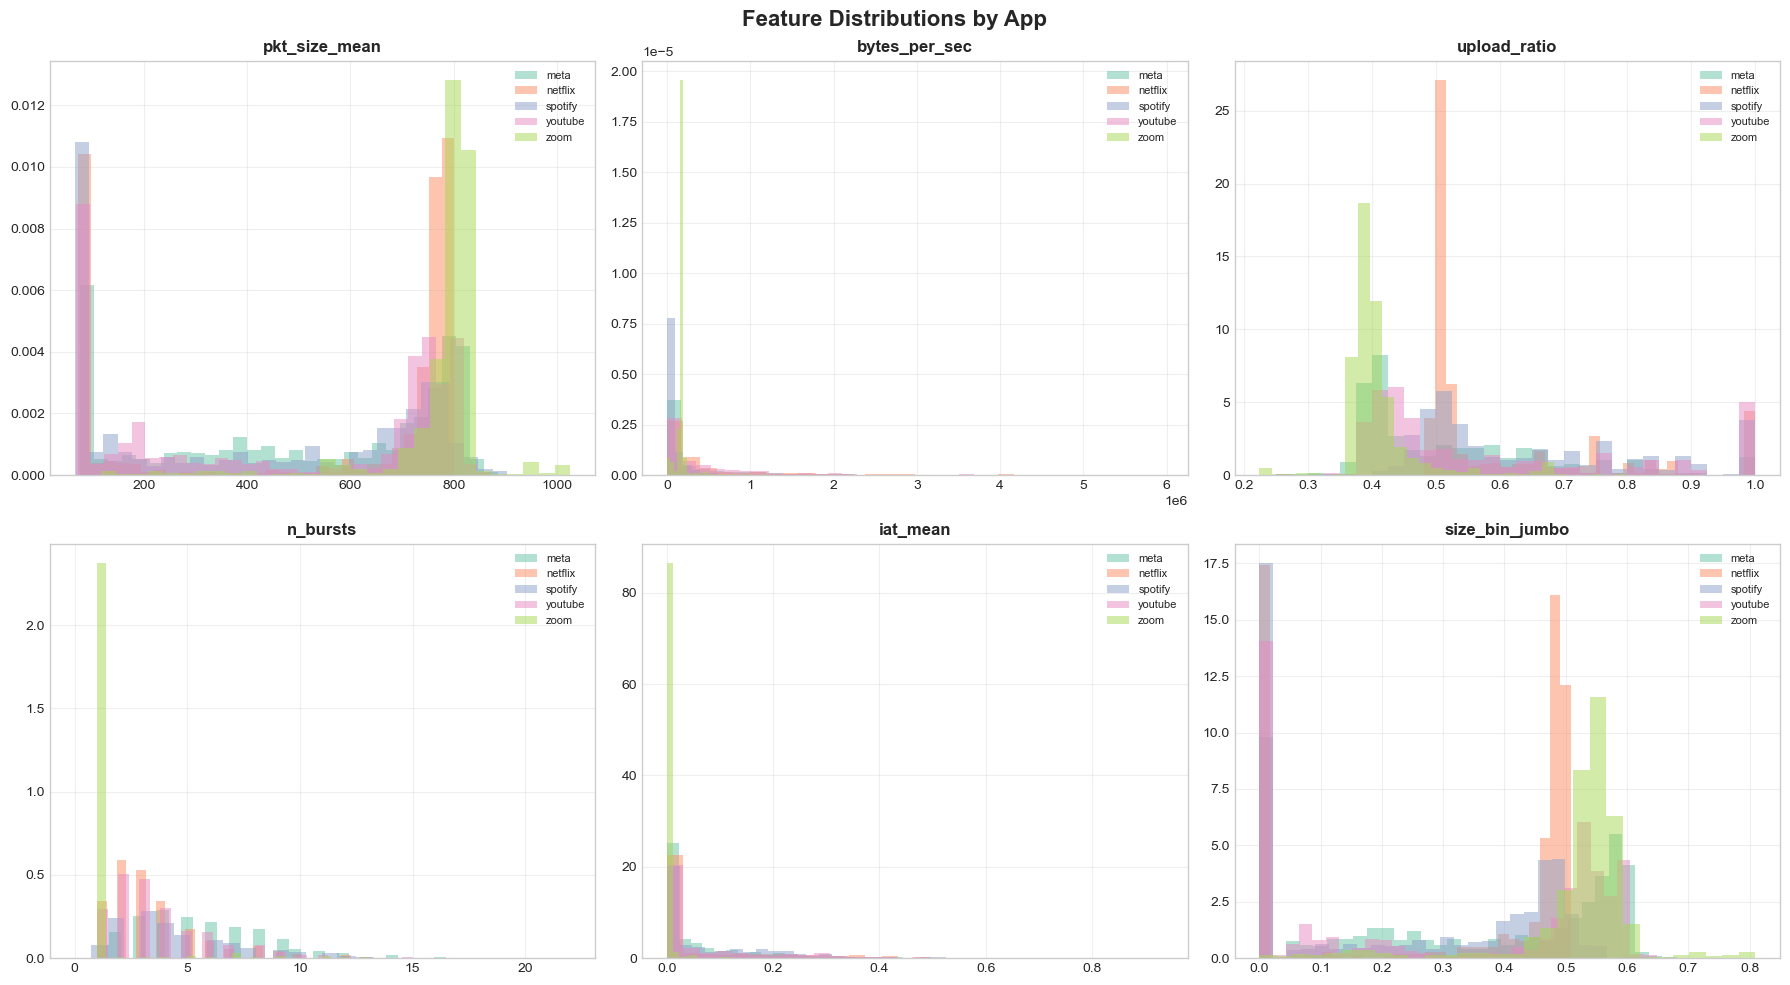

In [5]:
# 3.1 — Key feature distributions per app
key_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio', 
                'n_bursts', 'iat_mean', 'size_bin_jumbo']

# Only plot features that exist
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feat in enumerate(key_features):
    ax = axes[i//3][i%3]
    for app in df['app'].unique():
        subset = df[df['app'] == app][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=app, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by App', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3.2 — QUIC ratio per app (great discriminator)
if 'quic_ratio' in df.columns:
    fig = px.box(df, x='app', y='quic_ratio', color='app',
                 title='QUIC Protocol Usage by App',
                 labels={'quic_ratio': 'QUIC Ratio', 'app': 'App'})
    fig.update_layout(height=400, showlegend=False)
    fig.show()

In [7]:
# 3.3 — Upload vs Download ratio scatter
fig = px.scatter(df, x='upload_ratio', y='bytes_per_sec', color='app',
                 title='Upload Ratio vs Bandwidth by App',
                 labels={'upload_ratio': 'Upload Ratio', 'bytes_per_sec': 'Bytes/sec'},
                 opacity=0.6)
fig.update_layout(height=500)
fig.show()

In [8]:
# 3.4 — App traffic fingerprint radar chart
radar_features = ['pkt_size_mean', 'bytes_per_sec', 'upload_ratio',
                  'n_bursts', 'iat_mean', 'size_bin_jumbo']
radar_features = [f for f in radar_features if f in df.columns]

fig = go.Figure()
for app in df['app'].unique():
    subset = df[df['app'] == app][radar_features].mean()
    # Normalize to 0-1 for radar
    normalized = (subset - df[radar_features].min()) / (df[radar_features].max() - df[radar_features].min() + 1e-8)
    fig.add_trace(go.Scatterpolar(
        r=normalized.values.tolist() + [normalized.values[0]],
        theta=radar_features + [radar_features[0]],
        name=app, fill='toself', opacity=0.6
    ))
fig.update_layout(title='App Traffic Fingerprint Profiles', height=500,
                  polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

## 4. Feature Preparation

In [9]:
# 4.1 — Encode labels
le = LabelEncoder()
y = le.fit_transform(df['app'])
app_names = le.classes_
n_classes = len(app_names)

print(f'Classes ({n_classes}): {list(app_names)}')
print(f'Label mapping: {dict(zip(app_names, range(n_classes)))}')

Classes (5): ['meta', 'netflix', 'spotify', 'youtube', 'zoom']
Label mapping: {'meta': 0, 'netflix': 1, 'spotify': 2, 'youtube': 3, 'zoom': 4}


In [10]:
# 4.2 — Statistical features (for XGBoost)
stat_features = [
    'window_duration', 'total_packets', 'total_bytes',
    'packets_per_sec', 'bytes_per_sec',
    'pkt_size_mean', 'pkt_size_std', 'pkt_size_min', 'pkt_size_max',
    'pkt_size_median', 'pkt_size_q25', 'pkt_size_q75', 'pkt_size_skew', 'pkt_size_iqr',
    'size_bin_tiny', 'size_bin_small', 'size_bin_medium', 'size_bin_large', 'size_bin_jumbo',
    'payload_mean', 'payload_std', 'payload_max', 'payload_zero_ratio', 'payload_total',
    'iat_mean', 'iat_std', 'iat_min', 'iat_max', 'iat_median', 'iat_q25', 'iat_q75',
    'upload_packets', 'download_packets', 'upload_ratio', 'download_ratio', 'up_down_ratio',
    'up_bytes_total', 'up_size_mean', 'up_size_std', 'up_size_max',
    'down_bytes_total', 'down_size_mean', 'down_size_std', 'down_size_max',
    'up_iat_mean', 'up_iat_std', 'down_iat_mean', 'down_iat_std',
    'n_bursts', 'avg_burst_size', 'max_burst_size', 'burst_ratio',
    'n_unique_dst_ports', 'tcp_ratio', 'udp_ratio',
]

# Add quic_ratio if available
if 'quic_ratio' in df.columns:
    stat_features.append('quic_ratio')

available_stat = [f for f in stat_features if f in df.columns]
X_stat = df[available_stat].fillna(0).replace([np.inf, -np.inf], 0)

scaler = StandardScaler()
X_stat_scaled = pd.DataFrame(scaler.fit_transform(X_stat), columns=X_stat.columns)

print(f'Statistical features: {len(available_stat)}')

Statistical features: 56


In [11]:
# 4.3 — Packet Size Sequences (for 1D-CNN)
PSS_LENGTH = 50
pss_cols = [f'pss_{i}' for i in range(PSS_LENGTH)]
available_pss = [c for c in pss_cols if c in df.columns]

X_pss = df[available_pss].fillna(0).values
pss_max = np.max(np.abs(X_pss)) + 1e-8
X_pss_norm = X_pss / pss_max

print(f'PSS features: {len(available_pss)} (sequence length)')
print(f'PSS max value: {pss_max:.0f}')

PSS features: 50 (sequence length)
PSS max value: 1486


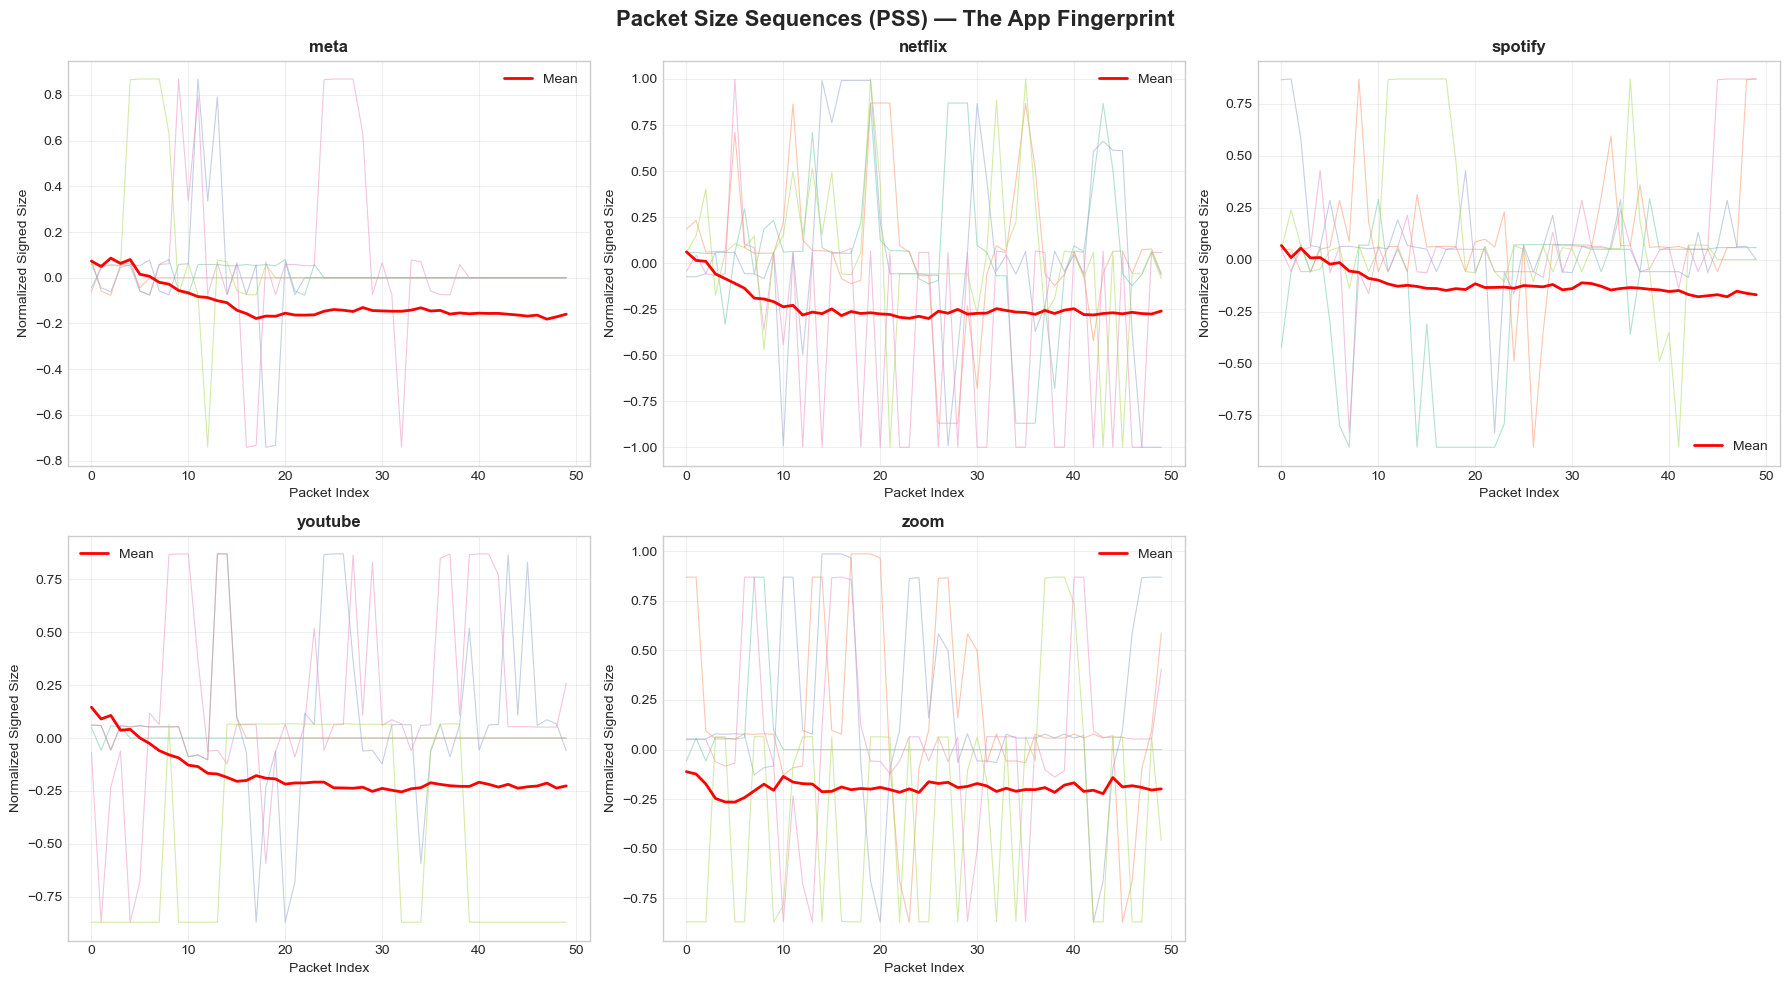

In [12]:
# 4.4 — Visualize PSS patterns per app
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, app in enumerate(app_names):
    ax = axes[idx//3][idx%3]
    app_mask = y == idx
    # Plot first 5 samples
    for i in range(min(5, app_mask.sum())):
        sample_idx = np.where(app_mask)[0][i]
        ax.plot(X_pss_norm[sample_idx], alpha=0.5, linewidth=0.8)
    # Plot mean
    ax.plot(X_pss_norm[app_mask].mean(axis=0), color='red', linewidth=2, label='Mean')
    ax.set_title(f'{app}', fontweight='bold')
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Normalized Signed Size')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide empty subplots if less than 6 apps
for idx in range(len(app_names), 6):
    axes[idx//3][idx%3].set_visible(False)

plt.suptitle('Packet Size Sequences (PSS) — The App Fingerprint', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_pss_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 4.5 — Train/Test Split
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_stat_train, X_stat_test = X_stat_scaled.iloc[train_idx], X_stat_scaled.iloc[test_idx]
X_pss_train, X_pss_test = X_pss_norm[train_idx], X_pss_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')
print(f'Train distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test distribution: {dict(zip(*np.unique(y_test, return_counts=True)))}')

Train: 3040 | Test: 761
Train distribution: {0: 629, 1: 566, 2: 600, 3: 606, 4: 639}
Test distribution: {0: 158, 1: 142, 2: 150, 3: 151, 4: 160}


## 5. Model Training

### 5.1 — XGBoost (Statistical Features)

XGBoost operates on hand-crafted statistical features extracted from each traffic window: packet sizes, inter-arrival times, direction ratios, burst patterns, and protocol ratios.

In [14]:
print('🚀 Training XGBoost on Statistical Features...')
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0,
)

xgb_model.fit(X_stat_train, y_train)
xgb_time = time.time() - start

xgb_pred = xgb_model.predict(X_stat_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='weighted')

print(f'\n  Accuracy: {xgb_acc:.4f}')
print(f'  F1-Score: {xgb_f1:.4f}')
print(f'  Time: {xgb_time:.2f}s')
print(f'\n{classification_report(y_test, xgb_pred, target_names=app_names)}')

🚀 Training XGBoost on Statistical Features...

  Accuracy: 0.8909
  F1-Score: 0.8914
  Time: 3.19s

              precision    recall  f1-score   support

        meta       0.94      0.89      0.92       158
     netflix       0.87      0.87      0.87       142
     spotify       0.82      0.84      0.83       150
     youtube       0.83      0.85      0.84       151
        zoom       0.99      0.99      0.99       160

    accuracy                           0.89       761
   macro avg       0.89      0.89      0.89       761
weighted avg       0.89      0.89      0.89       761



### 5.2 — 1D-CNN (Packet Size Sequences)

The 1D-CNN operates directly on raw packet size sequences — the core idea from PACKETPRINT. Each traffic window's first 50 packet sizes (signed: positive=upload, negative=download) form a 1D signal. The CNN learns spatial patterns in this signal that are unique to each app.

In [ ]:
# def augment_traffic_data(X, y, noise_level=0.02, shift_max=2):
#     """
#     X shape: (samples, sequence_length, 1)
#     """
#     # 1. Jittering: Add Gaussian noise to packet sizes
#     # We use a small noise_level to keep packet sizes realistic
#     noise = np.random.normal(0, noise_level * np.std(X), X.shape)
#     X_jitter = X + noise
    
#     # 2. Shifting: Roll the sequence horizontally
#     X_shift = np.copy(X)
#     for i in range(len(X_shift)):
#         shift = np.random.randint(-shift_max, shift_max + 1)
#         X_shift[i] = np.roll(X_shift[i], shift, axis=0)
    
#     # Combine original + jittered + shifted
#     X_augmented = np.vstack((X, X_jitter, X_shift))
#     y_augmented = np.concatenate((y, y, y))
    
#     # Shuffle the augmented set
#     indices = np.arange(len(X_augmented))
#     np.random.shuffle(indices)
    
#     return X_augmented[indices], y_augmented[indices]

# # Prepare the data
# # X_pss_train was your original packet size sequence
# X_train_cnn_base = X_pss_train.reshape(-1, X_pss_train.shape[1], 1)

# X_train_aug, y_train_aug = augment_traffic_data(X_train_cnn_base, y_train)

# print(f"📊 Original Training Set: {len(X_train_cnn_base)}")
# print(f"🚀 Augmented Training Set: {len(X_train_aug)}")

📊 Original Training Set: 3040
🚀 Augmented Training Set: 9120


In [15]:
print('🧠 Training Improved 1D-CNN on Packet Size Sequences...')

start = time.time()

# === 1. Reshape (already done) ===
X_train_cnn = X_pss_train.reshape(-1, X_pss_train.shape[1], 1)
X_test_cnn  = X_pss_test.reshape(-1, X_pss_test.shape[1], 1)

# === 2. Improved Model ===
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),
    
    # Block 1 — local patterns
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    
    # Block 2 — medium-range bursts (larger kernel + dilation)
    Conv1D(128, kernel_size=5, dilation_rate=2, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    
    # Block 3 — long-range patterns
    Conv1D(128, kernel_size=3, dilation_rate=1, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),
    
    # Block 4 — deeper features
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(n_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),   # clipnorm helps stability
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# === 3. Better callbacks ===
callbacks = [
    EarlyStopping(monitor='val_loss', patience=60, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=1)
]

history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=200,
    batch_size=64,                    # increased batch size (usually helps)
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

cnn_time = time.time() - start

# === 4. Evaluation ===
cnn_pred = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)
cnn_acc = accuracy_score(y_test, cnn_pred)
cnn_f1  = f1_score(y_test, cnn_pred, average='weighted')

print(f'\n✅ Improved Accuracy: {cnn_acc:.4f}')
print(f'   F1-Score         : {cnn_f1:.4f}')
print(f'   Training time    : {cnn_time:.2f}s')
print(f'\n{classification_report(y_test, cnn_pred, target_names=app_names)}')

🧠 Training Improved 1D-CNN on Packet Size Sequences...


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 50, 64)            256       
                                                                 
 batch_normalization (Batch  (None, 50, 64)            256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 25, 64)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 25, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 25, 128)           41088     
                                                                 
 batch_normalization_1 (Bat  (None, 25, 128)           5

2026-03-29 02:54:37.297170: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-03-29 02:54:37.469032: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


41/41 [==============================] - 7s 64ms/step - loss: 1.6222 - accuracy: 0.3785 - val_loss: 1.7925 - val_accuracy: 0.1711 - lr: 0.0010
Epoch 2/200
41/41 [==============================] - 1s 34ms/step - loss: 1.2989 - accuracy: 0.4377 - val_loss: 2.0412 - val_accuracy: 0.2215 - lr: 0.0010
Epoch 3/200
41/41 [==============================] - 1s 34ms/step - loss: 1.1859 - accuracy: 0.4950 - val_loss: 2.5775 - val_accuracy: 0.2215 - lr: 0.0010
Epoch 4/200
41/41 [==============================] - 1s 34ms/step - loss: 1.1206 - accuracy: 0.5081 - val_loss: 2.9739 - val_accuracy: 0.2215 - lr: 0.0010
Epoch 5/200
41/41 [==============================] - 1s 37ms/step - loss: 1.0663 - accuracy: 0.5372 - val_loss: 3.5974 - val_accuracy: 0.2215 - lr: 0.0010
Epoch 6/200
41/41 [==============================] - 1s 36ms/step - loss: 0.9821 - accuracy: 0.5728 - val_loss: 5.1515 - val_accuracy: 0.2215 - lr: 0.0010
Epoch 7/200
41/41 [==============================] - 1s 34ms/step - loss: 0.9611 -

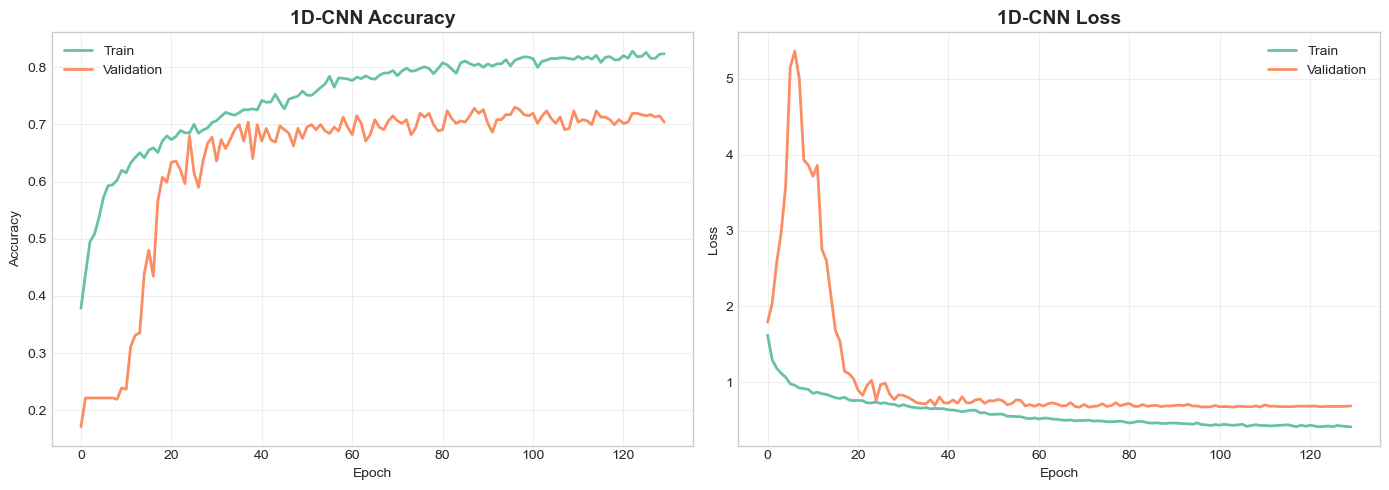

In [16]:
# CNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('1D-CNN Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('1D-CNN Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('app_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Comparison

In [17]:
# 6.1 — Results Table
results_df = pd.DataFrame({
    'Model': ['XGBoost', '1D-CNN'],
    'Features': ['Statistical (hand-crafted)', 'Packet Size Sequences (raw)'],
    'Accuracy': [xgb_acc, cnn_acc],
    'F1-Score': [xgb_f1, cnn_f1],
    'Training Time': [f'{xgb_time:.1f}s', f'{cnn_time:.1f}s'],
})

print('\n' + '=' * 70)
print('📊 APP FINGERPRINTING — MODEL COMPARISON')
print('=' * 70)
print(results_df.to_string(index=False))


📊 APP FINGERPRINTING — MODEL COMPARISON
  Model                    Features  Accuracy  F1-Score Training Time
XGBoost  Statistical (hand-crafted)  0.890933  0.891351          3.2s
 1D-CNN Packet Size Sequences (raw)  0.726675  0.728838        192.4s


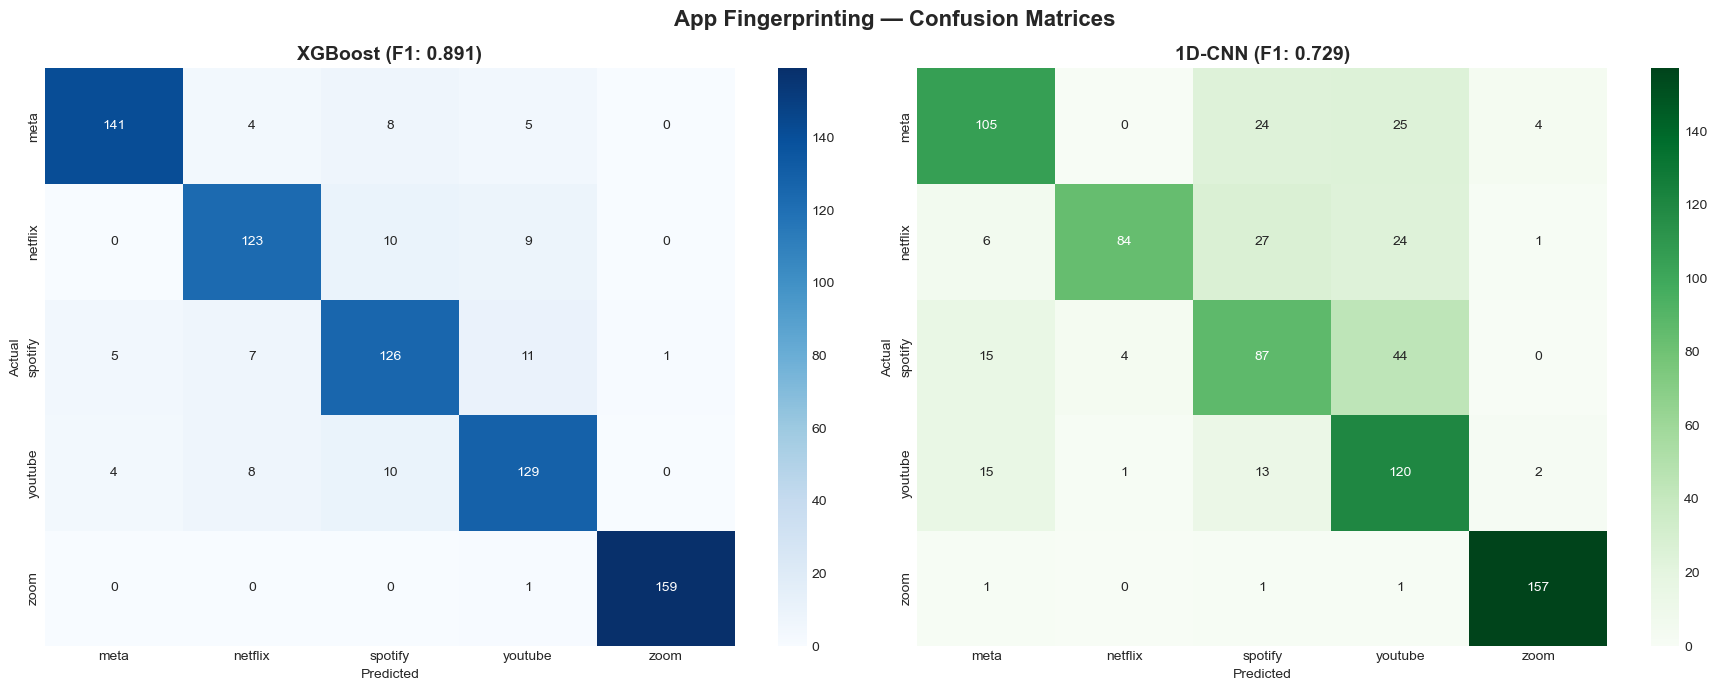

In [18]:
# 6.2 — Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=app_names, yticklabels=app_names)
axes[0].set_title(f'XGBoost (F1: {xgb_f1:.3f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_cnn = confusion_matrix(y_test, cnn_pred)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=app_names, yticklabels=app_names)
axes[1].set_title(f'1D-CNN (F1: {cnn_f1:.3f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('App Fingerprinting — Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('app_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

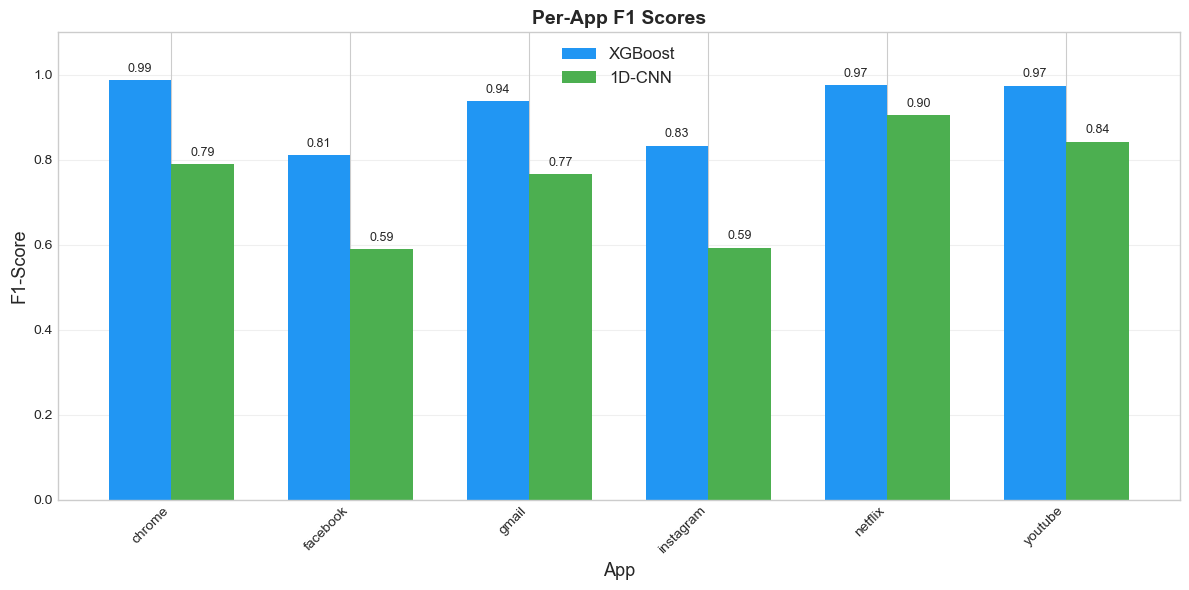

In [28]:
# 6.3 — Per-App F1 Scores
xgb_per = f1_score(y_test, xgb_pred, average=None)
cnn_per = f1_score(y_test, cnn_pred, average=None)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(n_classes)
width = 0.35

ax.bar(x - width/2, xgb_per, width, label='XGBoost', color='#2196F3')
ax.bar(x + width/2, cnn_per, width, label='1D-CNN', color='#4CAF50')

ax.set_xlabel('App', fontsize=13)
ax.set_ylabel('F1-Score', fontsize=13)
ax.set_title('Per-App F1 Scores', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(app_names, rotation=45, ha='right')
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (v1, v2) in enumerate(zip(xgb_per, cnn_per)):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.02, f'{v2:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('app_per_app_f1.png', dpi=150, bbox_inches='tight')
plt.show()

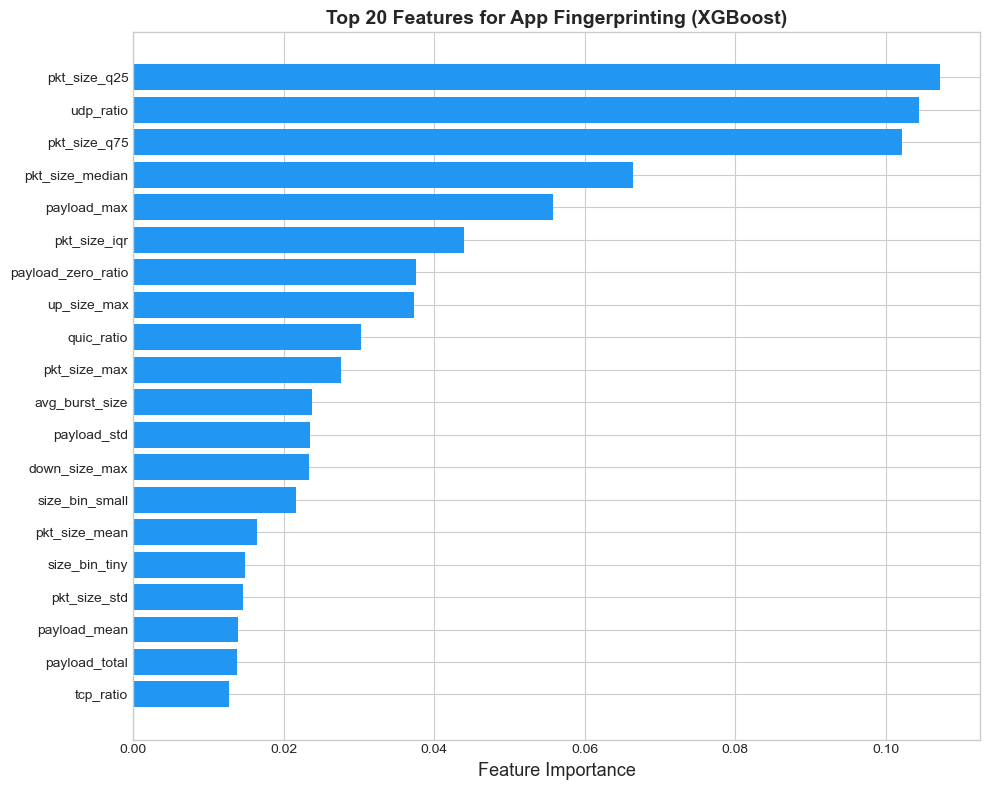

In [19]:
# 6.4 — XGBoost Feature Importance
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': available_stat,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3')
ax.set_xlabel('Feature Importance', fontsize=13)
ax.set_title('Top 20 Features for App Fingerprinting (XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('app_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Validation

In [20]:
print('Running 5-Fold Cross Validation (XGBoost)...')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_stat_scaled, y), 1):
    model = XGBClassifier(n_estimators=100, max_depth=8, n_jobs=-1, 
                          random_state=42, verbosity=0, eval_metric='mlogloss',
                          use_label_encoder=False)
    model.fit(X_stat_scaled.iloc[tr_idx], y[tr_idx])
    preds = model.predict(X_stat_scaled.iloc[val_idx])
    f1 = f1_score(y[val_idx], preds, average='weighted')
    fold_scores.append(f1)
    print(f'  Fold {fold}: F1 = {f1:.4f}')

scores = np.array(fold_scores)
print(f'\n  Mean F1: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

Running 5-Fold Cross Validation (XGBoost)...
  Fold 1: F1 = 0.8953
  Fold 2: F1 = 0.8769
  Fold 3: F1 = 0.8839
  Fold 4: F1 = 0.8986
  Fold 5: F1 = 0.8898

  Mean F1: 0.8889 (+/- 0.0156)


## 8. Save Models

In [29]:
import os
import joblib

# === CREATE THE FOLDER ===
os.makedirs('models_2', exist_ok=True)

print('💾 Saving models to models_2/...')

# === SAVE EVERYTHING INSIDE models_2/ ===
joblib.dump(xgb_model,          'models_2/app_xgboost.pkl')
joblib.dump(le,                 'models_2/app_label_encoder.pkl')
joblib.dump(scaler,             'models_2/app_scaler.pkl')
joblib.dump(available_stat,     'models_2/app_stat_features.pkl')
joblib.dump(pss_max,            'models_2/app_pss_max.pkl')

# For the CNN (Keras/TensorFlow model)
cnn_model.save('models_2/app_cnn_model.keras')

print('✅ All models saved successfully!')

# === SHOW FILE SIZES ===
print('\n📁 Saved files in models_2/:')
total_size = 0
for f in os.listdir('models_2'):
    if f.startswith('app_'):
        size_kb = os.path.getsize(f'models_2/{f}') / 1024
        print(f'   {f}: {size_kb:.1f} KB')
        total_size += size_kb

print(f'\n📦 Total size: {total_size:.1f} KB')

💾 Saving models to models_2/...
✅ All models saved successfully!

📁 Saved files in models_2/:
   app_pss_max.pkl: 0.1 KB
   app_cnn_model.keras: 2060.5 KB
   app_scaler.pkl: 3.2 KB
   app_stat_features.pkl: 0.8 KB
   app_label_encoder.pkl: 0.6 KB
   app_xgboost.pkl: 2516.5 KB

📦 Total size: 4581.8 KB


## 9. Summary

### Key Findings

1. **Apps have distinct traffic fingerprints** — even with encryption, packet size patterns, timing, and protocol choices uniquely identify applications
2. **QUIC ratio is a strong discriminator** — YouTube uses QUIC almost exclusively, while Netflix primarily uses TCP
3. **Burst patterns differ** — Messaging apps (Instagram) have more bursts than streaming apps (Netflix/YouTube)
4. **Upload/download ratio reveals app type** — Streaming is download-heavy, browsing is more balanced

### Integration with NetSentinel

The trained XGBoost model is integrated into NetSentinel's real-time dashboard. During live capture, traffic is aggregated into sliding windows, features are extracted, and the model predicts which app generated each window of traffic.

---
*NetSentinel — AI-Powered Network Traffic Analysis & App Fingerprinting*